In [203]:
import pandas as pd
import torch
import torch.nn as nn
import kagglehub
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

In [204]:
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

In [205]:
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('stopwords')
nltk.download('punkt')




[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [206]:

path = kagglehub.dataset_download("rehanliaqat17/imbd-dataset") + "/IMDB_Dataset.csv"

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'imbd-dataset' dataset.
Path to dataset files: /kaggle/input/imbd-dataset/IMDB_Dataset.csv


In [207]:
df = pd.read_csv(path)
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [208]:
df['sentiment'] = df['sentiment'].map({
    "positive":1,
    "negative":0
})
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [209]:
df['length'] = df['review'].apply(lambda x: len(x.split()))


## 4.1 Exploratory Data Analysis (EDA)

Let's visualize some aspects of our data, such as review length distribution and sentiment distribution, to gain insights.

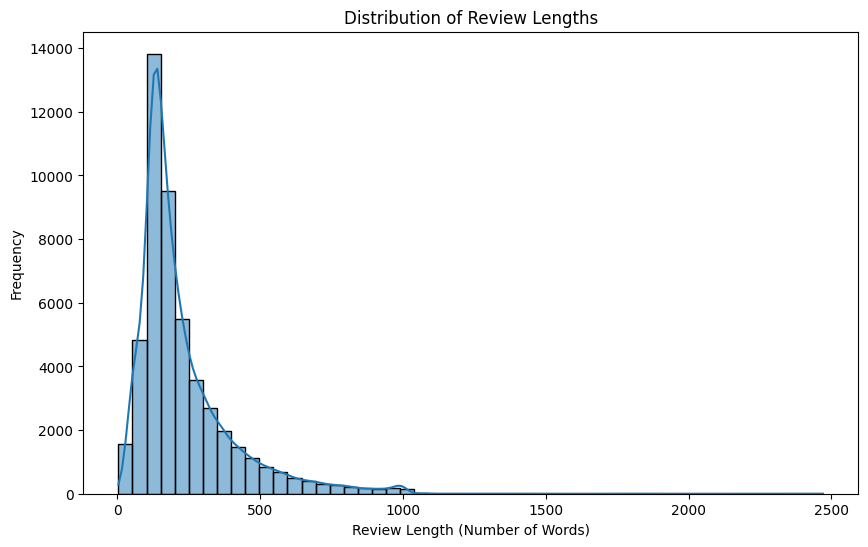

In [210]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the distribution of review lengths
plt.figure(figsize=(10, 6))
sns.histplot(df['length'], bins=50, kde=True)
plt.title('Distribution of Review Lengths')
plt.xlabel('Review Length (Number of Words)')
plt.ylabel('Frequency')
plt.show()

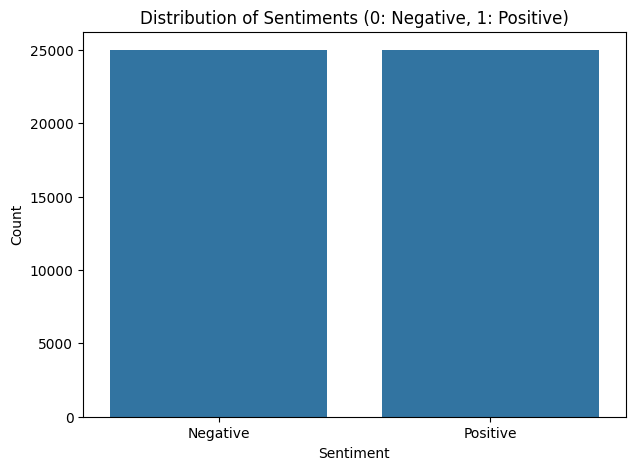

In [211]:
# Plotting the distribution of sentiments
plt.figure(figsize=(7, 5))
sns.countplot(x='sentiment', data=df)
plt.title('Distribution of Sentiments (0: Negative, 1: Positive)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.show()

In [212]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_map = {'J': wordnet.ADJ, 'V': wordnet.VERB, 'N': wordnet.NOUN, 'R': wordnet.ADV}
    return tag_map.get(tag, wordnet.NOUN)

In [213]:
import string

def preprocess_text(text:str):
    #remove punctuation , lowercassing, stopword removals
    stop_words = set(stopwords.words('english'))
    text = text.lower()
    text = ' '.join([word for word in text.split() if word.lower() not in stop_words])
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = ' '.join([lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in text.split()])
    return text.split()

tokenized_corpus = [preprocess_text(sentence) for sentence in df['review']]
vocab = {
    "<PAD>":0,
    "<UNK>":1
}
for review in tokenized_corpus:
    for word in review:
        if word not in vocab:
            vocab[word] = vocab.__len__()
vocab_size = vocab.__len__()

In [214]:
def encoder_decoder(key:str|int):
    if type(key) is str:
        return vocab[key]
    elif type(key) is int:
        return list(vocab.keys())[key]
    else:
        raise TypeError("please enter either a string or an integer")

In [215]:
MAX_LEN = 256

tensor_reviews = [torch.tensor([encoder_decoder(word) for word in review[:MAX_LEN]]) for review in tokenized_corpus]
labels = torch.tensor(df['sentiment'].values)

In [216]:
padded_reviews = pad_sequence(tensor_reviews, batch_first=True, padding_value=vocab["<PAD>"])

In [217]:
x_train, x_test, y_train, y_test = train_test_split(padded_reviews, labels, test_size=0.2, random_state=SEED)
train_ds = TensorDataset(x_train, y_train)
test_ds = TensorDataset(x_test, y_test)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=64)

In [218]:
class SentimentModel(nn.Module):

    def __init__(self, vocab_size:int):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=256,
            padding_idx=0
        )

        self.lstm = nn.LSTM(input_size=256, hidden_size=256, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(256, 1)
        self.sigmoid = nn.Sigmoid()


    def forward(self, x):
        lengths = (x != 0).sum(dim=1).cpu()

        x = self.embedding(x)

        packed = pack_padded_sequence(
            x,
            lengths,
            batch_first=True,
            enforce_sorted=False
        )

        output, (hidden, cell) = self.lstm(packed)
        # hidden shape: (num_layers, batch, hidden_size) — take the last layer
        hidden = hidden[-1]
        hidden = self.dropout(hidden)
        x = self.fc(hidden)
        x = self.sigmoid(x)

        return x

In [219]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [220]:
model = SentimentModel(vocab_size)
model.to(device)
criterion = nn.BCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [221]:
epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for X_batch, y_batch in train_dl:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch.float())

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

        correct = ((outputs >= 0.5).long() == y_batch).sum().item()
        accuracy = correct / y_batch.size(0)

    avg_loss = total_loss / len(train_dl)
    #test the model on the test set
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_dl:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch).squeeze()
            predicted = (outputs >= 0.5).long()
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
    test_accuracy = correct / total

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1, Loss: 0.4903, Accuracy: 0.8281, Test Accuracy: 0.8055
Epoch 2, Loss: 0.3098, Accuracy: 0.8750, Test Accuracy: 0.8726
Epoch 3, Loss: 0.2029, Accuracy: 0.9844, Test Accuracy: 0.8685
Epoch 4, Loss: 0.1282, Accuracy: 0.9062, Test Accuracy: 0.8757
Epoch 5, Loss: 0.0671, Accuracy: 0.9844, Test Accuracy: 0.8728
Epoch 6, Loss: 0.0344, Accuracy: 0.9844, Test Accuracy: 0.8755
Epoch 7, Loss: 0.0189, Accuracy: 0.9844, Test Accuracy: 0.8687
Epoch 8, Loss: 0.0146, Accuracy: 1.0000, Test Accuracy: 0.8713
Epoch 9, Loss: 0.0134, Accuracy: 1.0000, Test Accuracy: 0.8719
Epoch 10, Loss: 0.0122, Accuracy: 1.0000, Test Accuracy: 0.8745


In [222]:
model.eval()

total_loss = 0
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_dl:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device) # Move tensors to the correct device
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch.float())
        total_loss += loss.item()

        predicted = (outputs >= 0.5).long()
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

avg_loss = total_loss / len(test_dl)
accuracy = correct / total
print(f"Test Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

Test Loss: 0.6646, Accuracy: 0.8745


In [223]:
torch.save(model.state_dict(), "sentiment_model.pth")

In [224]:
model.load_state_dict(torch.load("sentiment_model.pth"))
model.eval()


SentimentModel(
  (embedding): Embedding(163593, 256, padding_idx=0)
  (lstm): LSTM(256, 256, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)